Install the packages

In [ ]:
%pip install numpy matplotlib opencv-python scikit-learn scikit-image imutils seaborn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25891 sha256=11cf19eb8b9a5fc32e314ffbbdb25ab803cd14e5c7c18cda4f09a89adfaf1c44
  Stored in directory: c:\users\win11\appdata\local\pip\cache\wheels\5b\76\96\ad0c321506837bef578cf3008df3916c23018435a355d9f6b1
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\Win11\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# All required packages installed in previous cell

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 1.1/1.1 MB 6.9 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requ

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-llms-openai 0.3.33 requires openai<2.0.0,>=1.66.3, but you have openai 2.16.0 which is incompatible.
realtimestt 0.3.98 requires soundfile==0.13.1, but you have soundfile 0.12.1 which is incompatible.
realtimestt 0.3.98 requires websockets==14.2, but you have websockets 15.0.1 which is incompatible.

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\Win11\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Import related Libraries

In [8]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.9 MB 4.8 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.9 MB 5.9 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/11.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------- ----------- 8.4/11.9 MB 10.8 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 12.2 MB/s  0:00:01
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --------------------- ------------------ 6.6/12.3 MB 30.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 31.5 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 27.5 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   -----------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 1.0.8 requires fastapi==0.115.9, but you have fastapi 0.128.0 which is incompatible.
gradio 5.29.0 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
llama-index-llms-openai 0.3.33 requires openai<2.0.0,>=1.66.3, but you have openai 2.16.0 which is incompatible.
realtimestt 0.3.98 requires numpy<2.0.0, but you have numpy 2.4.4 which is incompatible.
realtimestt 0.3.98 requires soundfile==0.13.1, but you have soundfile 0.12.1 which is incompatible.
realtimestt 0.3.98 requires websockets==14.2, but you have websockets 15.0.1 which is incompatible.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.1.0 which is incompatible.

[notice] A new release of pip is avai

In [5]:
# Libraries for data processing visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imutils import paths
import random
import seaborn as sns
import time
from datetime import datetime

In [9]:
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from skimage.feature import hog

In [10]:
# Libraries for image pre-processing and classification
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Image 

In [11]:
# Load images from local folder
image_folder = r"D:\Student\Projects\Computer Vision and Image processing\images"

# Get all image paths using imutils
image_paths = list(paths.list_images(image_folder))
print(f"Total images found: {len(image_paths)}")
for path in image_paths[:5]:
    print(path)

Total images found: 453
D:\Student\Projects\Computer Vision and Image processing\images\baboon.png
D:\Student\Projects\Computer Vision and Image processing\images\barbara.png
D:\Student\Projects\Computer Vision and Image processing\images\cameraman.jpeg
D:\Student\Projects\Computer Vision and Image processing\images\cat.jpg
D:\Student\Projects\Computer Vision and Image processing\images\cat2.jpg


In [12]:
# Extract labels from folder structure
# Assumes: images/class_name/image1.jpg structure
images = []
labels = []

for image_path in image_paths:
    try:
        # Extract class label from parent directory name
        class_name = os.path.basename(os.path.dirname(image_path))
        labels.append(class_name)
        
        # Load and convert to grayscale
        image = cv2.imread(image_path)
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            images.append(image)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")

# Create label mapping
unique_labels = sorted(set(labels))
label_dict = {label: idx for idx, label in enumerate(unique_labels)}
numeric_labels = np.array([label_dict[label] for label in labels])

print(f"Loaded {len(images)} images")
print(f"Classes: {unique_labels}")
print(f"Label distribution: {np.bincount(numeric_labels)}")

Loaded 248 images
Classes: ['images', 'new images', 'not_stop', 'stop', 'test_set_stop_not_stop']
Label distribution: [ 20  20 200 194  19]


In [15]:
# Feature Extraction: Histogram of Oriented Gradients (HOG)
# HOG captures shape and structure while being robust to lighting changes
features_list = []
resized_size = (64, 64)

for image in images:
    # Resize for consistency
    resized = cv2.resize(image, resized_size)
    
    # Extract HOG features
    hog_features = hog(resized, orientations=8, pixels_per_cell=(8, 8), 
                       cells_per_block=(2, 2), visualize=False)
    features_list.append(hog_features)

X = np.array(features_list)
y = numeric_labels

print(f"Feature matrix shape: {X.shape}")
print(f"Feature dimension: {X.shape[1]} (vs raw pixels: {resized_size[0]*resized_size[1]})")

Feature matrix shape: (248, 1568)
Feature dimension: 1568 (vs raw pixels: 4096)


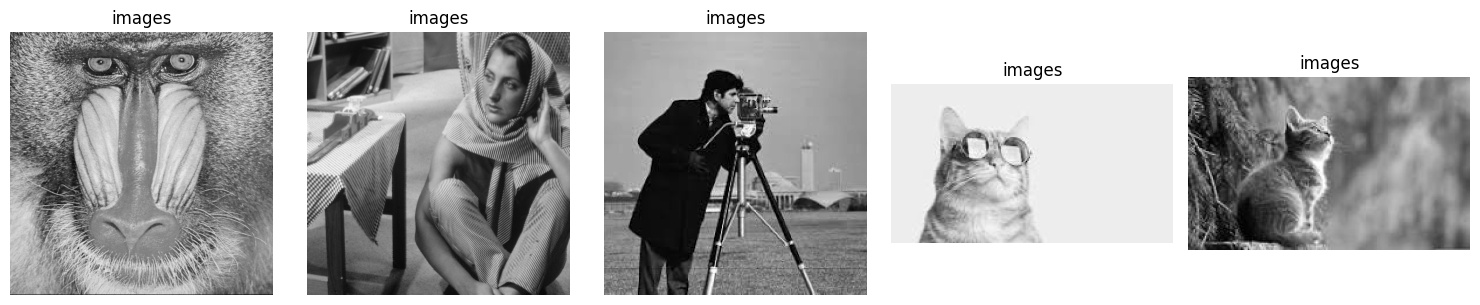

In [16]:
# Display sample images with their labels
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for idx in range(min(5, len(images))):
    axes[idx].imshow(images[idx], cmap='gray')
    axes[idx].set_title(unique_labels[numeric_labels[idx]])
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

In [17]:
# Select a random image to visualize
random_idx = random.randint(0, len(images)-1)
sample_image = images[random_idx]
sample_label = unique_labels[numeric_labels[random_idx]]

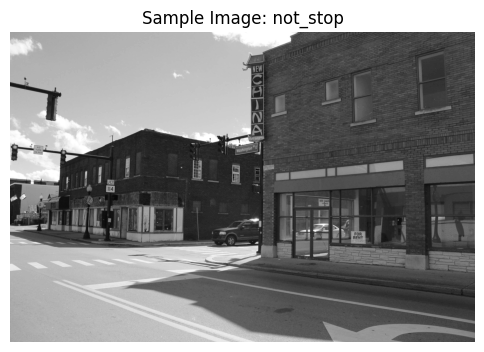

In [18]:
# Display the selected image
plt.figure(figsize=(6, 6))
plt.imshow(sample_image, cmap='gray')
plt.title(f'Sample Image: {sample_label}')
plt.axis('off')
plt.show()

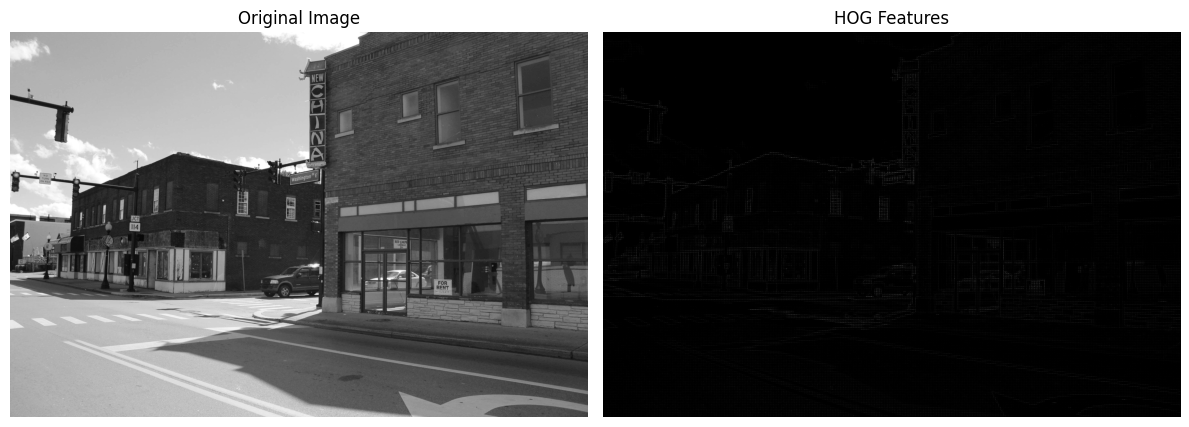

In [19]:
# Show HOG features for the sample image
hog_features_sample, hog_image = hog(sample_image, orientations=8, 
                                      pixels_per_cell=(8, 8), 
                                      cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(sample_image, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(hog_image, cmap='gray')
ax2.set_title('HOG Features')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# Compare raw pixels vs HOG features
resized_sample = cv2.resize(sample_image, (64, 64))
raw_pixels = resized_sample.flatten()
hog_features_sample = hog(resized_sample, orientations=8, 
                          pixels_per_cell=(8, 8), 
                          cells_per_block=(2, 2), visualize=False)

print(f"Raw pixel features: {raw_pixels.shape[0]} dimensions")
print(f"HOG features: {hog_features_sample.shape[0]} dimensions")
print(f"Feature reduction: {100 * (1 - hog_features_sample.shape[0]/raw_pixels.shape[0]):.1f}%")

Raw pixel features: 4096 dimensions
HOG features: 1568 dimensions
Feature reduction: 61.7%


In [21]:
# Train-Test Split with stratification to ensure balanced class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Training feature shape: {X_train.shape}")

ValueError: Found input variables with inconsistent numbers of samples: [248, 453]

In [ ]:
# Train KNN with different K values
from time import time

start_time = time()

k_values = [1, 3, 5, 7, 9]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Get predictions
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    knn_results[k] = {
        'model': knn,
        'predictions': y_pred,
        'accuracy': accuracy
    }
    
    print(f"K={k}: Accuracy = {accuracy:.4f}")

end_time = time()
print(f"\nTraining Duration: {end_time - start_time:.4f} seconds")

# Find best K
best_k = max(knn_results.items(), key=lambda x: x[1]['accuracy'])[0]
print(f"\nBest K value: {best_k} with accuracy: {knn_results[best_k]['accuracy']:.4f}")

In [ ]:
# Compare with other classifiers
from time import time

classifiers = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42)
}

comparison_results = {}

for name, clf in classifiers.items():
    start_time = time()
    clf.fit(X_train, y_train)
    train_time = time() - start_time
    
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    comparison_results[name] = {
        'model': clf,
        'predictions': y_pred,
        'accuracy': accuracy,
        'train_time': train_time
    }
    
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Training time: {train_time:.4f}s")

In [ ]:
# Display detailed classification reports
for name, results in comparison_results.items():
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, results['predictions'], 
                                target_names=unique_labels))

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
model_names = list(comparison_results.keys())
accuracies = [comparison_results[name]['accuracy'] for name in model_names]

axes[0].bar(model_names, accuracies, color=['blue', 'green', 'red'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Training time comparison
train_times = [comparison_results[name]['train_time'] for name in model_names]

axes[1].bar(model_names, train_times, color=['blue', 'green', 'red'])
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time Comparison')
for i, v in enumerate(train_times):
    axes[1].text(i, v + 0.01, f'{v:.3f}s', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix for Best KNN Model
best_model = knn_results[best_k]['model']
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (KNN, k={best_k})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix for Best Classifier (compare all models)
best_overall_model_name = max(comparison_results.items(), key=lambda x: x[1]['accuracy'])[0]
best_overall_model = comparison_results[best_overall_model_name]['model']
y_pred_overall = best_overall_model.predict(X_test)
cm_overall = confusion_matrix(y_test, y_pred_overall)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_overall, annot=True, fmt='d', cmap='Greens', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Best Model: {best_overall_model_name})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nBest Overall Model: {best_overall_model_name}")
print(f"Accuracy: {comparison_results[best_overall_model_name]['accuracy']:.4f}")

In [ ]:
# Summary Statistics
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nDataset Information:")
print(f"  - Total images: {len(images)}")
print(f"  - Classes: {unique_labels}")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Test samples: {X_test.shape[0]}")
print(f"  - Feature dimension (HOG): {X.shape[1]}")

print(f"\nModel Performance:")
for name, results in sorted(comparison_results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print(f"  {name}:")
    print(f"    - Accuracy: {results['accuracy']:.4f}")
    print(f"    - Training time: {results['train_time']:.4f}s")

print(f"\nBest Model: {best_overall_model_name}")
print(f"Best Accuracy: {comparison_results[best_overall_model_name]['accuracy']:.4f}")

In [ ]:
# Optional: Make predictions on new images
def predict_image(image_path, model, scaler=None):
    """Predict the class of a single image"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            return None, None
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        resized = cv2.resize(gray, (64, 64))
        features = hog(resized, orientations=8, pixels_per_cell=(8, 8), 
                       cells_per_block=(2, 2), visualize=False)
        features = features.reshape(1, -1)
        
        predicted_label_idx = model.predict(features)[0]
        predicted_label = unique_labels[predicted_label_idx]
        
        return predicted_label, gray
    except Exception as e:
        print(f"Error: {e}")
        return None, None

# Test on a random image from test set
test_idx = random.randint(0, len(X_test)-1)
test_features = X_test[test_idx].reshape(1, -1)
prediction = best_overall_model.predict(test_features)[0]
actual = y_test[test_idx]

print(f"Predicted: {unique_labels[prediction]}")
print(f"Actual: {unique_labels[actual]}")
print(f"Correct: {prediction == actual}")